In [1]:
import numpy as np
import healpy as hp
import pysm3 as sm

import matplotlib as mpl
import matplotlib.pyplot as plt

import cmasher as cmr
import seaborn as sns

import sys
sys.path.append('../')

from src.utils import pretty_axes, modify_rc, make_hist
modify_rc()
modify_rc()
from src import synthesize


In [2]:
NSIDE = 512
LMAX = 3*NSIDE - 1

ells = np.arange(LMAX+1)
alpha = 8./3.
L = 10.
target_cl = np.sqrt(ells**2 + L**2)**(-alpha)
target_cl[np.isnan(target_cl)|np.isinf(target_cl)] = 1e-15

t_delta_params = {
    'cl_target': target_cl,
    'cl_noise': target_cl,
    'c':5.0,
    'lambda':0.5,
    'anisotropy':'isotropic',
}
e_delta_params = {
    'cl_target': target_cl,
    'cl_noise':target_cl,
    'c':5.0,
    'lambda':0.5,
    'anisotropy':'isotropic',
}
b_delta_params = {
    'cl_target':target_cl,
    'cl_noise':target_cl,
    'c':5.0,
    'lambda':0.5,
    'anisotropy':'isotropic',
}

cl_tt, cl_ee, cl_bb, cl_te = 1.*target_cl, 0.75*target_cl, 0.2*target_cl, 0.3*target_cl

i_delta, q_delta, u_delta = synthesize.make_iqu(
    LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)

Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

In [3]:
import astropy.units as u
gaussian_filter = hp.smoothing

scales = np.exp(np.linspace(np.log(8), np.log(3*NSIDE-1), 16))

FIELD = i_delta
Ps = [1,2,3,4,5,6,7,8,9]
vals = {}
for p in Ps:
    vals[p] = np.zeros_like(scales)

for i, s in enumerate(scales):
    fwhm = (180.*u.deg/s).to_value(u.rad)
    df = FIELD - gaussian_filter(FIELD, fwhm)
    for p in Ps:
        vals[p][i] = np.nanmean(np.abs(df)**p)

Ps = np.array(Ps)


[]

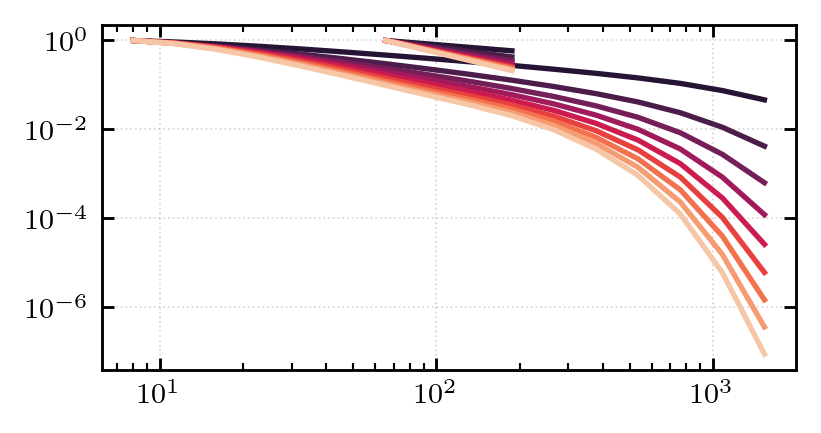

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

cols = sns.color_palette('rocket', n_colors=len(Ps))
for i in range(len(Ps)):
    sf_avg = vals[Ps[i]]
    _r = scales
    ax.plot(_r, sf_avg/sf_avg[0], color=cols[i])
    CUTOFF1 = 6
    CUTOFF2 = 10
    pow = np.polyfit(np.log(_r)[CUTOFF1:CUTOFF2], np.log(sf_avg)[CUTOFF1:CUTOFF2], deg=1)[0]
    ax.plot(_r[CUTOFF1:CUTOFF2], _r[CUTOFF1:CUTOFF2]**pow/np.nanmax(_r[CUTOFF1:CUTOFF2]**pow), color=cols[i])

pretty_axes(ax)
ax.loglog()

<>:49: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:49: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_66425/2018416564.py:49: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  cbar_ax.set_title('$\lambda$')


Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.225

Text(0.5, 1.0, '$\\lambda$')

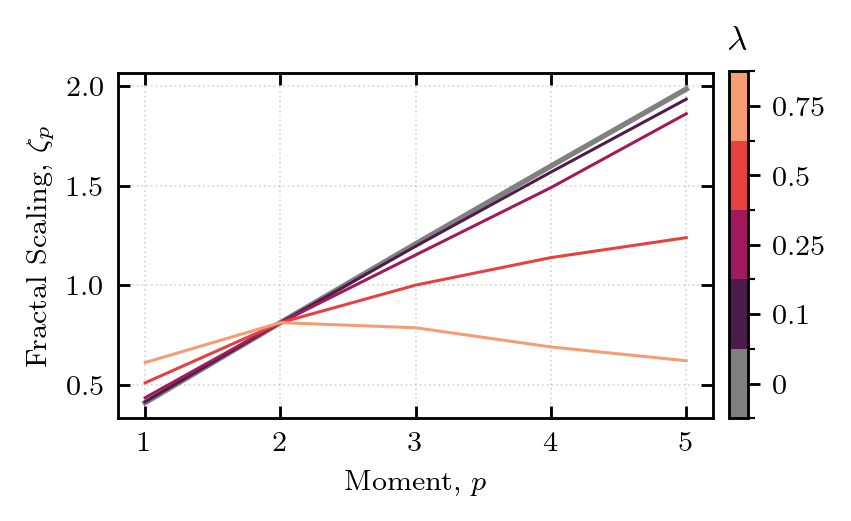

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(3., 1.75), dpi=256)

lambdas = [0.001, 0.1, 0.25, 0.5, 0.75]
cols = sns.color_palette('rocket', n_colors=len(lambdas)-1)

for _l, la in enumerate(lambdas):
    t_delta_params['lambda'] = la
    e_delta_params['lambda'] = la
    b_delta_params['lambda'] = la
    i_delta, q_delta, u_delta = synthesize.make_iqu(
        LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
    Ps = [1,2,3,4,5]
    vals = {}
    for p in Ps:
        vals[p] = np.zeros_like(scales)
    for i, s in enumerate(scales):
        fwhm = (180.*u.deg/s).to_value(u.rad)
        df = i_delta - gaussian_filter(i_delta, fwhm)
        for p in Ps:
            vals[p][i] = np.nanmean(np.abs(df)**p)
    zetas = []
    for i, p in enumerate(Ps):
        sf_avg = vals[Ps[i]]
        zetas.append(-np.polyfit(np.log(scales)[CUTOFF1:CUTOFF2], np.log(sf_avg)[CUTOFF1:CUTOFF2], deg=1)[0])
    if _l == 0:
        ax.plot(Ps, zetas, color='gray')
    else:
        ax.plot(Ps, zetas, color=cols[_l-1], linewidth=0.85)

pretty_axes(ax)
ax.set_ylabel(r'Fractal Scaling, $\zeta_p$')
ax.set_xlabel(r'Moment, $p$')

ax.set_xticks([1,2,3,4,5], ['$1$', '$2$', '$3$', '$4$', '$5$'])

from matplotlib.colors import ListedColormap, BoundaryNorm
colours = [(0.5, 0.5, 0.5)] + cols
cmap2 = ListedColormap(colours)
bounds = np.arange(len(colours)+1)
norm = BoundaryNorm(bounds, ncolors=len(colours))
im = plt.cm.ScalarMappable(cmap=cmap2, norm=norm)
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.11, 0.025, 0.775])
cbar = fig.colorbar(im, cax=cbar_ax)
centers = 0.5 + np.arange(len(colours))
cbar.set_ticks(centers)
cbar.set_ticklabels(['$0$', '$0.1$', '$0.25$', '$0.5$', '$0.75$'])
# cbar_ax.set_ylabel(r'Multifractal Parameter, $\lambda$')
cbar_ax.set_title('$\lambda$')


<>:51: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:51: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/tmp/ipykernel_66425/3585552535.py:51: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  cbar_ax.set_title('$\ell$', fontsize=8.)


[   8   32  128  512 1024] [0.39269908 0.09817477 0.02454369 0.00613592 0.00306796] [22.5         5.625       1.40625     0.3515625   0.17578125]
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640374956
Synthesizing band: 134.22202462496796
Synthesizing band: 268.92560942933255
Synthesizing band: 531.2684738740461
Synthesizing band: 822.2253637335211
Synthesizing band: 950.4012773896895
Synthesizing band: 21.031548644787264
Synthesizing band: 64.07036640

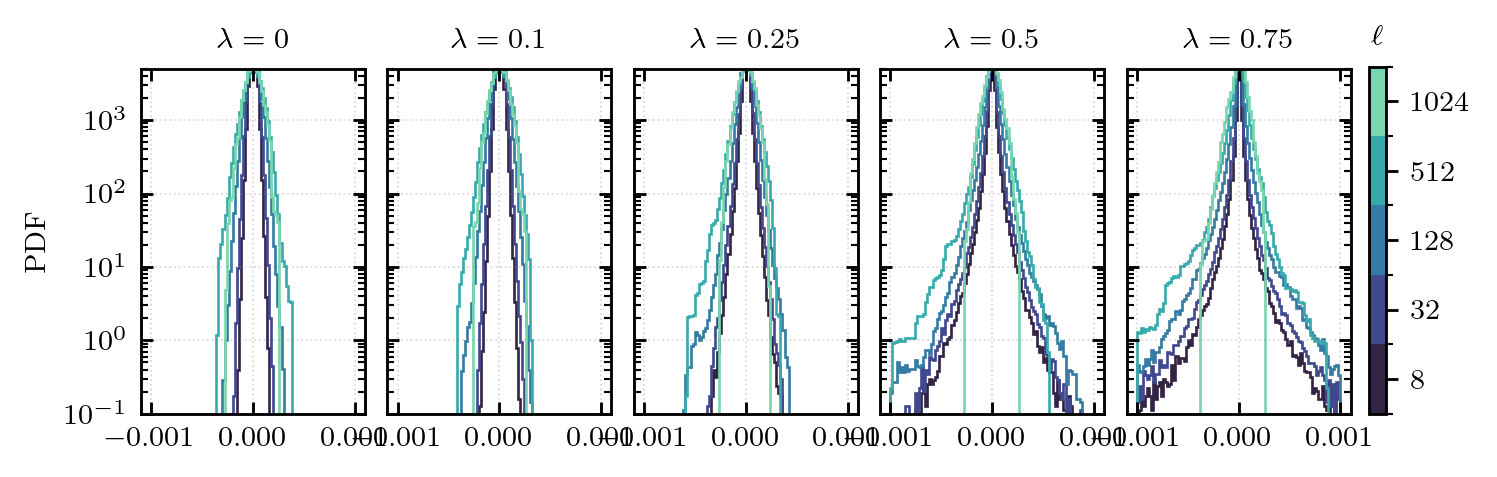

In [10]:

fig, ax = plt.subplots(1, len(lambdas), figsize=(7., 1.75), dpi=256)

# scales = np.exp(np.linspace(np.log(8), np.log(2*NSIDE), 5))
scales = np.array([8, 32, 128, 512, 1024])
print(scales, (180.*u.deg/scales).to_value(u.rad), (180.*u.deg/scales).to_value(u.deg))
cols = sns.color_palette('mako', len(scales))
ranges = [(-0.001, 0.001), ]

for _l, la in enumerate(lambdas):
    t_delta_params['lambda'] = la
    e_delta_params['lambda'] = la
    b_delta_params['lambda'] = la
    i_delta, q_delta, u_delta = synthesize.make_iqu(
        LMAX, NSIDE, t_delta_params, e_delta_params, b_delta_params, cl_tt, cl_ee, cl_bb, cl_te)
    for i, s in enumerate(scales[::-1]):
        fwhm1, fwhm2 = (180.*u.deg/s).to_value(u.rad)*np.sqrt(1.+1e-3), (180.*u.deg/s).to_value(u.rad)/np.sqrt(1.+1e-3)

        FIELD = hp.smoothing(i_delta, fwhm1) - hp.smoothing(i_delta, fwhm2)
        ax[_l].stairs(*make_hist((FIELD-np.nanmean(FIELD)), density=True, bin_num=100, range=ranges[0]), edgecolor=cols[i], linewidth=0.75)

for axx in ax:
    pretty_axes(axx)
    axx.set_yscale('log')
    # axx.set_xscale('symlog')
    axx.set_ylim((1e-1, 5e3))
ax[1].set_yticklabels([])
ax[2].set_yticklabels([])
ax[3].set_yticklabels([])
ax[4].set_yticklabels([])
ax[0].set_ylabel('PDF')

ax[0].set_title(r'$\lambda=0$', fontsize=8.)
ax[1].set_title(r'$\lambda=0.1$', fontsize=8.)
ax[2].set_title(r'$\lambda=0.25$', fontsize=8.)
ax[3].set_title(r'$\lambda=0.5$', fontsize=8.)
ax[4].set_title(r'$\lambda=0.75$', fontsize=8.)


from matplotlib.colors import ListedColormap, BoundaryNorm
colours = cols
cmap2 = ListedColormap(colours)

bounds = np.arange(len(colours)+1)
norm = BoundaryNorm(bounds, ncolors=len(colours))
im = plt.cm.ScalarMappable(cmap=cmap2, norm=norm)
fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.81, 0.11, 0.01, 0.775])
cbar = fig.colorbar(im, cax=cbar_ax)
centers = 0.5 + np.arange(len(colours))
cbar.set_ticks(centers)
cbar_ax.set_title('$\ell$', fontsize=8.)
cbar.set_ticklabels(['$8$', '$32$', '$128$', '$512$', '$1024$'])

fig.subplots_adjust(wspace=0.1)
